# Gamma Exponential Kernel: Exact vs RFF Approximation

This notebook demonstrates the Random Fourier Feature (RFF) approximation for the Gamma Exponential (Exponential Power) kernel.

## Kernel Definition

The Gamma Exponential kernel is defined as:
$$k(x, x') = \exp\left(-\|x - x'\|^\gamma\right)$$

where $\gamma \in (0, 2]$.

### Special Cases
- $\gamma = 2$: Gaussian (RBF) kernel
- $\gamma = 1$: Laplacian kernel

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/GeneralizedRFF.jl`


In [2]:
using GeneralizedRandomFourierFeatures
using KernelFunctions
using KernelFunctions: ColVecs
using AbstractGPs
using Random
using LinearAlgebra
using Plots
gr()

Random.seed!(42)

TaskLocalRNG()

## 1. Kernel Profile Comparison

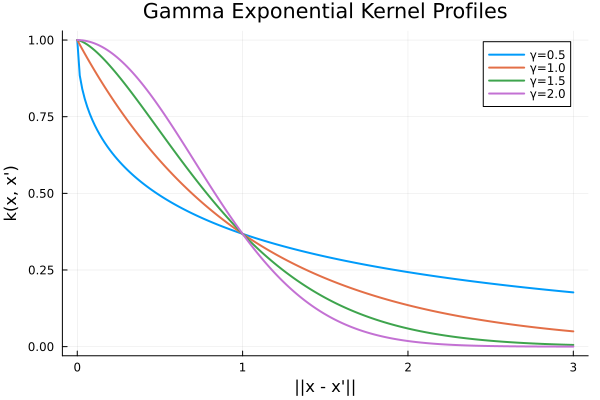

In [3]:
# Compare different gamma values
gamma_values = [0.5, 1.0, 1.5, 2.0]
x_range = range(0, 3, length=200)

p_profiles = plot(title="Gamma Exponential Kernel Profiles", 
                  xlabel="||x - x'||", ylabel="k(x, x')", legend=:topright)

for γ in gamma_values
    k = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=γ)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_profiles, x_range, y_k, label="γ=$γ", linewidth=2)
end

p_profiles

## 2. Kernel Matrix Comparison (Heatmap)

In [4]:
# Define kernel
γ = 1.5
k = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=γ)
println("Kernel: ", k)

Kernel: Gamma Exponential Kernel (γ = 1.5, metric = Distances.Euclidean(0.0))


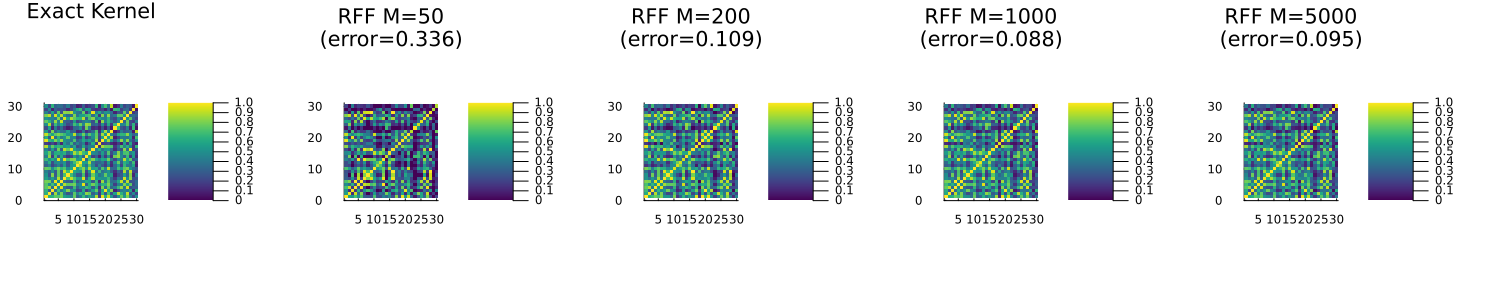

In [5]:
# Generate test data
n = 30
X = [rand(2) * 2 for _ in 1:n]

# Exact kernel matrix
K_exact = kernelmatrix(k, X)

# RFF approximation with different M values
M_values = [50, 200, 1000, 5000]

plots = [heatmap(K_exact, title="Exact Kernel", c=:viridis, aspect_ratio=1, clim=(0, 1))]

for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(plots, heatmap(K_approx, title="RFF M=$M\n(error=$(round(rel_error, digits=3)))", 
                         c=:viridis, aspect_ratio=1, clim=(0, 1)))
end

plot(plots..., layout=(1, 5), size=(1500, 300))

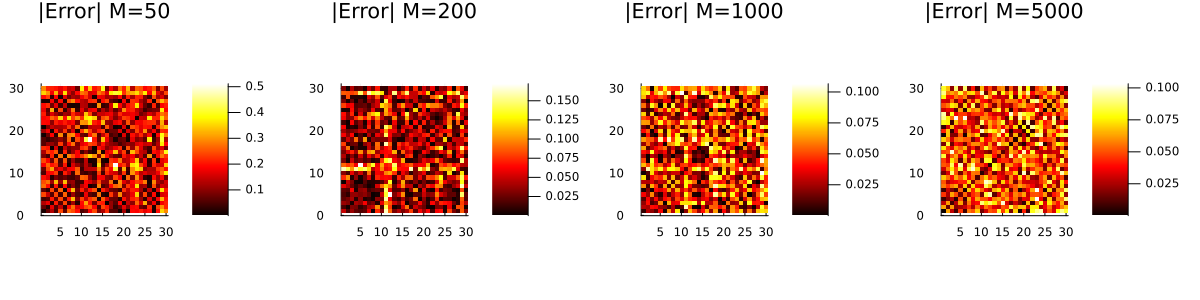

In [6]:
# Error difference heatmaps
error_plots = []
for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    K_diff = abs.(K_exact - K_approx)
    push!(error_plots, heatmap(K_diff, title="|Error| M=$M", c=:hot, aspect_ratio=1))
end

plot(error_plots..., layout=(1, 4), size=(1200, 300))

## 3. Convergence Analysis

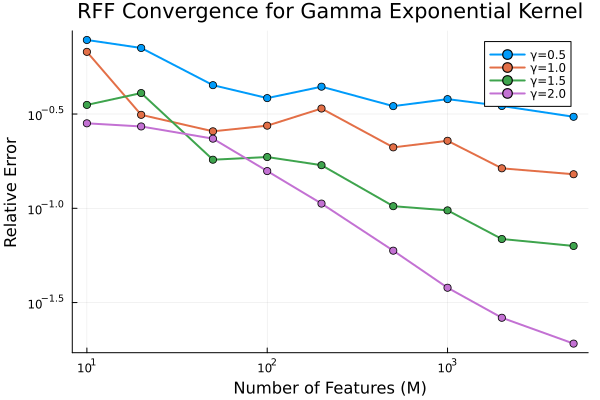

In [7]:
# Analyze convergence for different gamma values
M_range = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
gamma_test = [0.5, 1.0, 1.5, 2.0]

p_conv = plot(title="RFF Convergence for Gamma Exponential Kernel",
              xlabel="Number of Features (M)", ylabel="Relative Error",
              xscale=:log10, yscale=:log10, legend=:topright)

for γ in gamma_test
    k_γ = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=γ)
    K_exact_γ = kernelmatrix(k_γ, X)
    
    errors = Float64[]
    for M in M_range
        K_approx = rff_kernelmatrix(MersenneTwister(42), k_γ, X, M)
        rel_error = norm(K_exact_γ - K_approx) / norm(K_exact_γ)
        push!(errors, rel_error)
    end
    
    plot!(p_conv, M_range, errors, marker=:circle, label="γ=$γ", linewidth=2)
end

p_conv

## 4. 1D Gaussian Process Comparison

In [8]:
# RFF approximation for GP
function rff_gp_predict(k, X_train, y_train, X_test, M; noise=0.1)
    rng = MersenneTwister(42)
    d = length(first(X_train))
    basis = sample_generalized_rff_basis(rng, k, d, M)
    
    # Compute features
    Phi_train_mat = hcat(X_train...)
    Phi_test_mat = hcat(X_test...)
    
    features_train = basis(ColVecs(Phi_train_mat))
    features_test = basis(ColVecs(Phi_test_mat))
    
    Phi_train = hcat([features_train[i] for i in 1:length(X_train)]...)'
    Phi_test = hcat([features_test[i] for i in 1:length(X_test)]...)'
    
    # Bayesian linear regression with RFF features
    n, m = size(Phi_train)
    A = Phi_train' * Phi_train + noise^2 * I(m)
    w_mean = A \ (Phi_train' * y_train)
    
    # Predictive mean and variance
    m_pred = Phi_test * w_mean
    Sigma_w = noise^2 * inv(A)
    v_pred = [Phi_test[i, :]' * Sigma_w * Phi_test[i, :] + noise^2 for i in 1:size(Phi_test, 1)]
    
    return m_pred, sqrt.(v_pred)
end

rff_gp_predict (generic function with 1 method)

In [9]:
# Generate 1D data
n_train = 10
x_train = sort(rand(n_train) * 4 .- 2)
y_train = sin.(2 * x_train) .+ 0.2 * randn(n_train)

x_test = range(-2.5, 2.5, length=200)

X_train = [[x] for x in x_train]
X_test = [[x] for x in x_test]

# Exact GP
k_1d = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=1.5)
f_exact = GP(k_1d)
fx_exact = f_exact(X_train, 0.1)
p_exact = posterior(fx_exact, y_train)

m_exact = mean(p_exact(X_test))
s_exact = sqrt.(var(p_exact(X_test)))

200-element Vector{Float64}:
 0.9949894939368635
 0.9944763962968848
 0.9939150669788667
 0.9933014614175417
 0.9926312484613826
 0.9918997953936747
 0.9911021526856805
 0.990233038529955
 0.9892868232074716
 0.9882575133479324
 0.9871387361484298
 0.9859237236214581
 0.9846052969491077
 ⋮
 0.6202040998820233
 0.640964688102171
 0.6608365140010856
 0.6798411335659801
 0.6980008548725252
 0.7153385291867127
 0.731877396529756
 0.7476409666221773
 0.7626529231983837
 0.7769370440726947
 0.7905171320981504
 0.8034169539142503

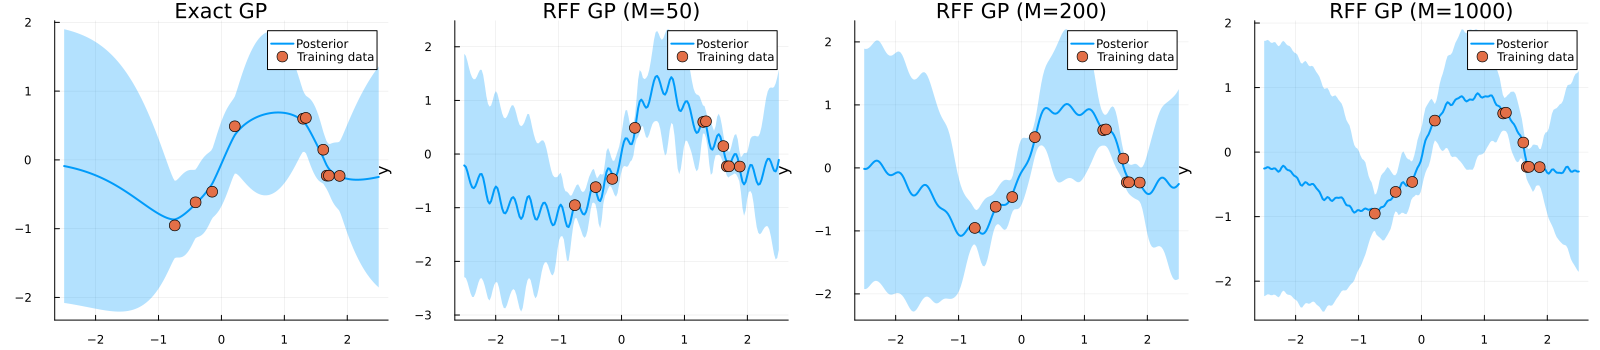

In [10]:
# Compare GP predictions
p1 = plot(title="Exact GP", xlabel="x", ylabel="y", legend=:topright)
plot!(p1, x_test, m_exact, ribbon=2*s_exact, fillalpha=0.3, label="Posterior", linewidth=2)
scatter!(p1, x_train, y_train, label="Training data", markersize=6)

M_vals = [50, 200, 1000]
rff_plots = []
for M in M_vals
    m_rff, s_rff = rff_gp_predict(k_1d, X_train, y_train, X_test, M)
    p = plot(title="RFF GP (M=$M)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Training data", markersize=6)
    push!(rff_plots, p)
end

plot(p1, rff_plots..., layout=(1, 4), size=(1600, 350))

## 5. 2D Gaussian Process Comparison

In [11]:
# Generate 2D data
n_train_2d = 30
X_train_2d = [rand(2) * 4 .- 2 for _ in 1:n_train_2d]
y_train_2d = [sin(x[1]) * cos(x[2]) + 0.1 * randn() for x in X_train_2d]

# Test grid
x1_range = range(-2.5, 2.5, length=40)
x2_range = range(-2.5, 2.5, length=40)
X_test_2d = [[x1, x2] for x1 in x1_range for x2 in x2_range]

1600-element Vector{Vector{Float64}}:
 [-2.5, -2.5]
 [-2.5, -2.371794871794872]
 [-2.5, -2.2435897435897436]
 [-2.5, -2.1153846153846154]
 [-2.5, -1.9871794871794872]
 [-2.5, -1.858974358974359]
 [-2.5, -1.7307692307692308]
 [-2.5, -1.6025641025641026]
 [-2.5, -1.4743589743589745]
 [-2.5, -1.3461538461538463]
 [-2.5, -1.2179487179487178]
 [-2.5, -1.0897435897435896]
 [-2.5, -0.9615384615384616]
 ⋮
 [2.5, 1.0897435897435896]
 [2.5, 1.2179487179487178]
 [2.5, 1.3461538461538463]
 [2.5, 1.4743589743589745]
 [2.5, 1.6025641025641026]
 [2.5, 1.7307692307692308]
 [2.5, 1.858974358974359]
 [2.5, 1.9871794871794872]
 [2.5, 2.1153846153846154]
 [2.5, 2.2435897435897436]
 [2.5, 2.371794871794872]
 [2.5, 2.5]

In [12]:
# Exact GP for 2D
k_2d = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=1.5)
f_exact_2d = GP(k_2d)
fx_exact_2d = f_exact_2d(X_train_2d, 0.1)
p_exact_2d = posterior(fx_exact_2d, y_train_2d)

m_exact_2d = mean(p_exact_2d(X_test_2d))
m_exact_grid = reshape(m_exact_2d, length(x1_range), length(x2_range))

40×40 Matrix{Float64}:
 -0.000536851   0.000559293   0.00191022   …  -0.120735    -0.0987304
 -0.0046172    -0.00379857   -0.00268093      -0.119616    -0.0950467
 -0.0106802    -0.0103702    -0.00970009      -0.109745    -0.0835783
 -0.0192923    -0.0198157    -0.0198949       -0.0884648   -0.0624654
 -0.031086     -0.0328905    -0.0341402       -0.0536358   -0.0304373
 -0.0467269    -0.0504136    -0.0534166    …  -0.00451425   0.0126343
 -0.0668551    -0.0732042    -0.0787492        0.0574661    0.0652954
 -0.0920022    -0.101979     -0.111086         0.128518     0.124402
 -0.12249      -0.137218     -0.151111         0.202919     0.185396
 -0.158325     -0.17902      -0.199042         0.273628     0.242903
 -0.199114     -0.227        -0.254495     …   0.333253     0.291736
 -0.244        -0.280227     -0.316457         0.376353     0.328355
 -0.291617     -0.337184     -0.383286         0.402408     0.352108
  ⋮                                        ⋱               
 -0.191051   

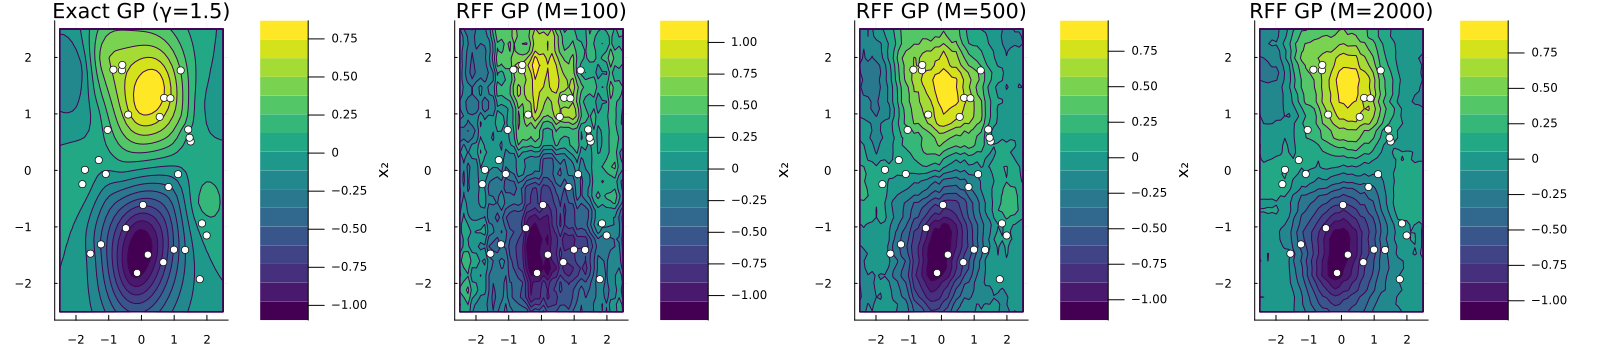

In [13]:
# Plot 2D comparison
p_exact_plot = contourf(x1_range, x2_range, m_exact_grid', 
                        title="Exact GP (γ=1.5)", xlabel="x₁", ylabel="x₂", c=:viridis)
scatter!(p_exact_plot, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
         c=:white, markersize=4, label="")

rff_2d_plots = [p_exact_plot]
for M in [100, 500, 2000]
    m_rff_2d, _ = rff_gp_predict(k_2d, X_train_2d, y_train_2d, X_test_2d, M)
    m_rff_grid = reshape(m_rff_2d, length(x1_range), length(x2_range))
    
    p_rff = contourf(x1_range, x2_range, m_rff_grid', 
                     title="RFF GP (M=$M)", xlabel="x₁", ylabel="x₂", c=:viridis)
    scatter!(p_rff, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
             c=:white, markersize=4, label="")
    push!(rff_2d_plots, p_rff)
end

plot(rff_2d_plots..., layout=(1, 4), size=(1600, 350))

## 6. Comparison with Special Cases (γ=1, γ=2)

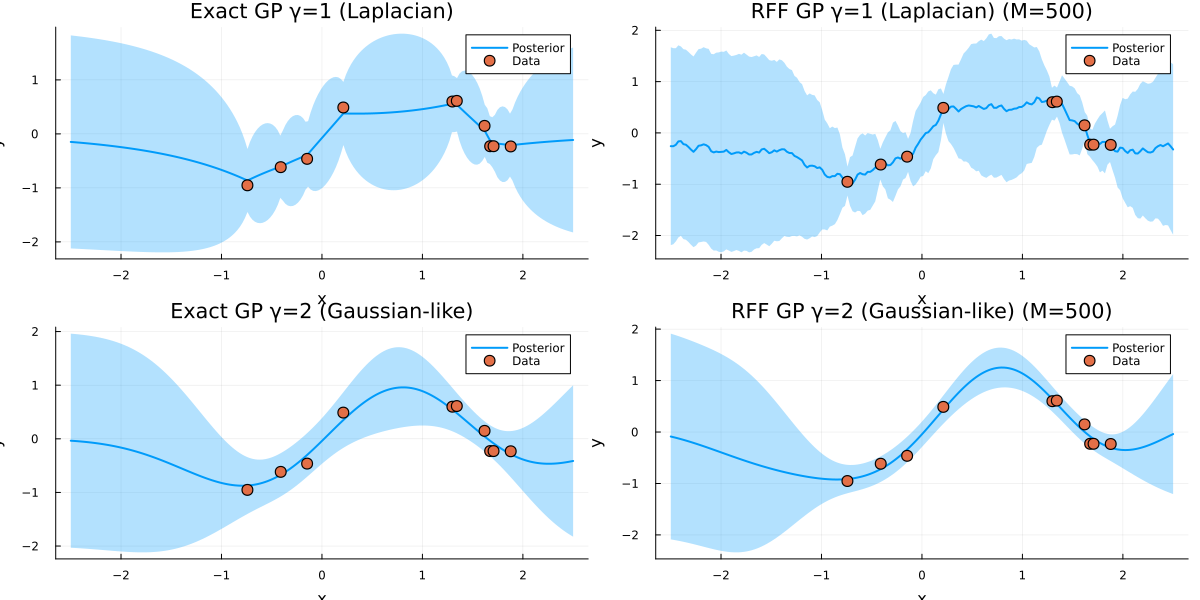

In [14]:
# Compare γ=1 (Laplacian) and γ=2 (Gaussian-like)
k_lap = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=1.0)  # Laplacian
k_gauss = GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=2.0)  # Gaussian-like

# 1D GP comparison for different gamma
gp_plots = []

for (k, name) in [(k_lap, "γ=1 (Laplacian)"), (k_gauss, "γ=2 (Gaussian-like)")]
    f = GP(k)
    fx = f(X_train, 0.1)
    p_post = posterior(fx, y_train)
    
    m = mean(p_post(X_test))
    s = sqrt.(var(p_post(X_test)))
    
    p = plot(title="Exact GP $name", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m, ribbon=2*s, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Data", markersize=6)
    push!(gp_plots, p)
    
    # RFF approximation
    m_rff, s_rff = rff_gp_predict(k, X_train, y_train, X_test, 500)
    p_rff = plot(title="RFF GP $name (M=500)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p_rff, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p_rff, x_train, y_train, label="Data", markersize=6)
    push!(gp_plots, p_rff)
end

plot(gp_plots..., layout=(2, 2), size=(1200, 600))

## Summary

The Gamma Exponential kernel RFF approximation:
- Works well for all γ ∈ (0, 2]
- Special cases γ=1 (Laplacian) and γ=2 (Gaussian-like) are well approximated
- Convergence rate depends on γ, with smaller γ potentially requiring more features